# Day 5 — Identity graph

Signal 2: catches "sloppy" fraud rings that share infrastructure (same card, address, or email) across multiple transactions/accounts.

**`isFraud` is not used anywhere in this notebook.** The graph is built purely from shared attributes; whether the resulting structure actually concentrates real fraud is evaluated later, on Day 7, specifically so the evaluation is genuine and not circular.

In [1]:
import sys, time
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from src.data import load_merged_train
from src.graph import build_identity_graph, save_graph, IDENTITY_ATTRIBUTES, DEFAULT_TIME_WINDOW_SECONDS, DEFAULT_MAX_GROUP_SIZE

train = load_merged_train()
print(train.shape)

(590540, 434)


## 1. Which attributes actually carry identity signal?

The plan calls for edges from `card1-card6`, `addr1/addr2`, `P_emaildomain`. Before using all of them, check what each one's value distribution actually looks like — sharing a value is only meaningful evidence if that value isn't already shared by half the dataset.

In [2]:
candidate_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain']

rows = []
for col in candidate_cols:
    vc = train[col].value_counts()
    rows.append({
        'column': col,
        'nunique': train[col].nunique(),
        'top_value_count': vc.iloc[0],
        'top_value_share': vc.iloc[0] / len(train),
        'median_group_size': vc.median(),
    })

cardinality = pd.DataFrame(rows).set_index('column')
cardinality

,nunique,top_value_count,top_value_share,median_group_size
column,,,,
card1,13553,14932,0.025285,4.0
card2,500,48935,0.082865,176.0
card3,114,521287,0.882729,10.0
card4,4,384767,0.651551,98772.5
card5,119,296546,0.502161,13.0
card6,4,439938,0.744976,74508.0
addr1,332,46335,0.078462,3.0
addr2,74,520481,0.881365,3.5
P_emaildomain,59,228355,0.386688,305.0


**Reading this table:** `card3`, `card4`, `card5`, `card6`, and `addr2` are each dominated by one or two near-universal values (e.g. one `card4` value alone covers 65% of all transactions — that's the card network, like "Visa", not a card identifier). Sharing one of these tells you nothing about being the same account; it just means two people both used a Visa card. `card1`, `card2`, and `addr1` have enough distinct values with small typical group sizes to plausibly represent an actual shared card or address. `P_emaildomain` sits in between — most domains are small, but a few (Gmail, Yahoo, Hotmail) are extremely common; the graph builder's `max_group_size` cap (below) handles this automatically rather than needing to hand-pick which domains to exclude.

**Identity-graph attributes used:** `card1`, `card2`, `addr1`, `P_emaildomain`. `card3/4/5/6` and `addr2` are excluded — not because of missing data (they're 99-100% populated) but because their values are too coarse to mean "the same identity."

## 2. Build the graph

- **Nodes**: one per transaction (`TransactionID`) — the dataset has no persistent account ID, so transactions standing in for accounts is the practical unit, same approach used in published graph-based fraud research on this dataset.
- **Edges**: two transactions connect if they share an attribute value **and** fall within a 24-hour time window of each other (`DEFAULT_TIME_WINDOW_SECONDS`) — real rings operate in bursts, not across the full 6-month span.
- **Weight**: inverse frequency of the shared value (`1 / group_size`) — a rare shared email counts far more than a common one. A pair sharing multiple attributes gets summed weight across them.
- **Scale guard**: attribute values shared by more than 1,000 transactions (`DEFAULT_MAX_GROUP_SIZE`) are skipped entirely — building edges for something like "gmail.com" would be computationally wasteful and contribute a near-zero weight anyway.

In [3]:
print(f'attributes: {IDENTITY_ATTRIBUTES}')
print(f'time window: {DEFAULT_TIME_WINDOW_SECONDS}s ({DEFAULT_TIME_WINDOW_SECONDS/3600:.0f}h)')
print(f'max group size: {DEFAULT_MAX_GROUP_SIZE}')

t0 = time.time()
graph = build_identity_graph(train)
t1 = time.time()

print(f'\nBuilt in {t1 - t0:.1f}s')

attributes: ['card1', 'card2', 'addr1', 'P_emaildomain']
time window: 86400s (24h)
max group size: 1000



Built in 4.7s


## 3. Graph statistics

In [4]:
n_nodes = graph.number_of_nodes()
n_edges = graph.number_of_edges()
degrees = dict(graph.degree())
non_isolated = sum(1 for d in degrees.values() if d > 0)

print(f'Nodes (transactions): {n_nodes:,}')
print(f'Edges: {n_edges:,}')
print(f'Non-isolated nodes: {non_isolated:,} ({non_isolated / n_nodes:.1%} of all transactions)')

components = list(nx.connected_components(graph))
component_sizes = sorted((len(c) for c in components), reverse=True)
non_trivial_components = [s for s in component_sizes if s > 1]

print(f'\nConnected components: {len(components):,} total')
print(f'Non-trivial components (size > 1): {len(non_trivial_components):,}')
print(f'Largest component size: {component_sizes[0]:,}')
print(f'Median non-trivial component size: {pd.Series(non_trivial_components).median():.0f}')

Nodes (transactions): 590,540
Edges: 803,453
Non-isolated nodes: 242,644 (41.1% of all transactions)



Connected components: 385,709 total
Non-trivial components (size > 1): 37,813
Largest component size: 49,294
Median non-trivial component size: 3


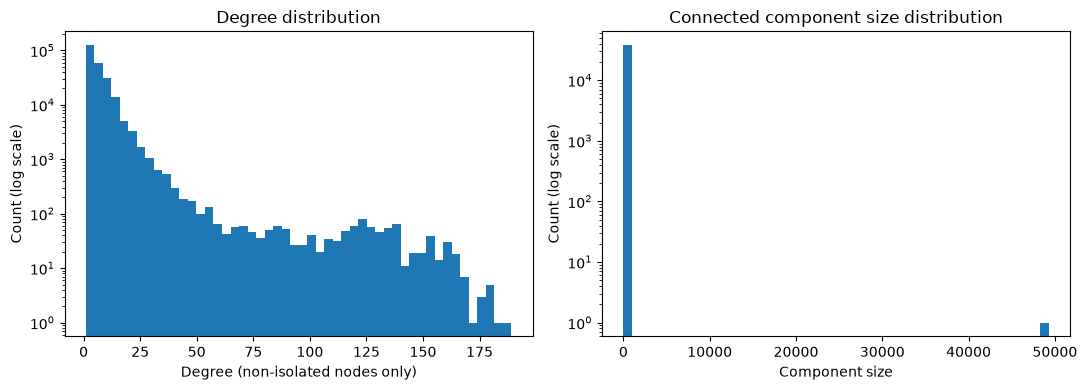

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

degree_values = [d for d in degrees.values() if d > 0]
axes[0].hist(degree_values, bins=50)
axes[0].set_yscale('log')
axes[0].set_xlabel('Degree (non-isolated nodes only)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Degree distribution')

axes[1].hist(non_trivial_components, bins=50)
axes[1].set_yscale('log')
axes[1].set_xlabel('Component size')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Connected component size distribution')

plt.tight_layout()
plt.show()

Edge weight summary:
count    803453.000000
mean          0.006542
std           0.021909
min           0.001004
25%           0.001269
50%           0.002053
75%           0.004032
max           1.000000
dtype: float64


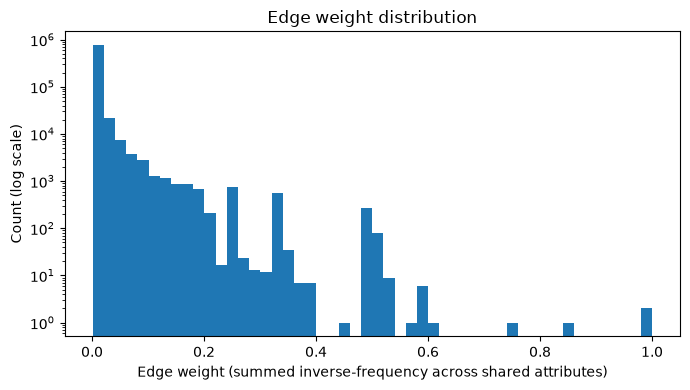

In [6]:
weights = [w for _, _, w in graph.edges(data='weight')]
print('Edge weight summary:')
print(pd.Series(weights).describe())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(weights, bins=50)
ax.set_yscale('log')
ax.set_xlabel('Edge weight (summed inverse-frequency across shared attributes)')
ax.set_ylabel('Count (log scale)')
ax.set_title('Edge weight distribution')
plt.tight_layout()
plt.show()

## 4. Save for reuse

Day 6 combines this with the behavioral-similarity graph before running Louvain clustering — save it here rather than rebuilding it.

In [7]:
save_graph(graph, '../data/processed/identity_graph.pkl')
print('Saved to data/processed/identity_graph.pkl')

Saved to data/processed/identity_graph.pkl


## Takeaway

_Fill in after running: how many transactions ended up connected to at least one other, how large the biggest clusters are, and whether that looks like a plausible mix of small genuine-sharing groups (e.g. a household) vs. anything unusually large that might need a tighter time window or lower max-group-size._